# Exploring energy data


In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import requests as req
import io
import geopandas as gpd
import folium




In [2]:
import matplotlib.pyplot as plt
import streamlit

In [3]:
from ydata_profiling import ProfileReport

/var/folders/jj/z6z8sj0x5kn824vb1cnls1z00000gn/T/ipykernel_36464/44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install data-profiling via `pip install data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


- Checking ydata-profiling installation / environment 

In [3]:
try:
    import ydata_profiling
    print("ydata_profiling is installed correctly")
except Exception as e:
    print("Error:", e)


ydata_profiling is installed correctly


In [4]:
import sys
print(sys.executable)


/Users/anjanid/projects/energy_data/energy_env_p3.10.13/bin/python


In [8]:
# This is the direct link to the 'Electricity Capacity 2026' CSV from the Open Gov portal
url = "https://www.cer-rec.gc.ca/open/energy/energyfutures2026/electricity-capacity-2026.csv"

# Load directly into your project
df = pd.read_csv(url)

df.head()


,Scenario,Region,Variable,Type,Year,Value
0,Canada Net-zero,Alberta,Battery Storage,Primary Fuel,2005,0.0
1,Canada Net-zero,Alberta,Battery Storage,Primary Fuel,2006,0.0
2,Canada Net-zero,Alberta,Battery Storage,Primary Fuel,2007,0.0
3,Canada Net-zero,Alberta,Battery Storage,Primary Fuel,2008,0.0
4,Canada Net-zero,Alberta,Battery Storage,Primary Fuel,2009,0.0


In [ ]:
df.describe(include = 'all')

# df.describe()

,Scenario,Region,Variable,Type,Year,Value
count,19401,19401,19401,19401,19401.000000,19401.000000
unique,4,14,10,1,NaN,NaN
top,Canada Net-zero,Canada,Battery Storage,Primary Fuel,NaN,NaN
freq,4881,1840,2576,19401,NaN,NaN
mean,NaN,NaN,NaN,NaN,2027.463017,3775.038983
std,NaN,NaN,NaN,NaN,13.292913,11452.635869
min,NaN,NaN,NaN,NaN,2005.000000,0.000000
25%,NaN,NaN,NaN,NaN,2016.000000,14.500000
50%,NaN,NaN,NaN,NaN,2027.000000,248.522000
75%,NaN,NaN,NaN,NaN,2039.000000,1511.040000


In [11]:
df.Scenario.unique()

array(['Canada Net-zero', 'Current Measures', 'Higher Scenario',
       'Lower Scenario'], dtype=object)

In [13]:
df.Variable.unique()

array(['Battery Storage', 'Biomass / Geothermal', 'Coal & Coke',
       'Hydro / Wave / Tidal', 'Natural Gas', 'Oil', 'Solar', 'Uranium',
       'Wind', 'Hydrogen'], dtype=object)

In [5]:
df_canada = df[df['Region'] == 'Canada'].pivot_table(
    index = 'Year',
    columns ='Scenario',
    values = 'Value'
).sort_index()

In [6]:
df_canada.head()

Scenario,Canada Net-zero,Current Measures,Higher Scenario,Lower Scenario
Year,,,,
2005,12196.86429,12196.86429,12196.86429,12196.86429
2006,12326.04230,12326.04230,12326.04230,12326.04230
2007,12463.53330,12463.53330,12463.53330,12463.53330
2008,12754.64331,12754.64331,12754.64331,12754.64331
2009,12899.27630,12899.27630,12899.27630,12899.27630


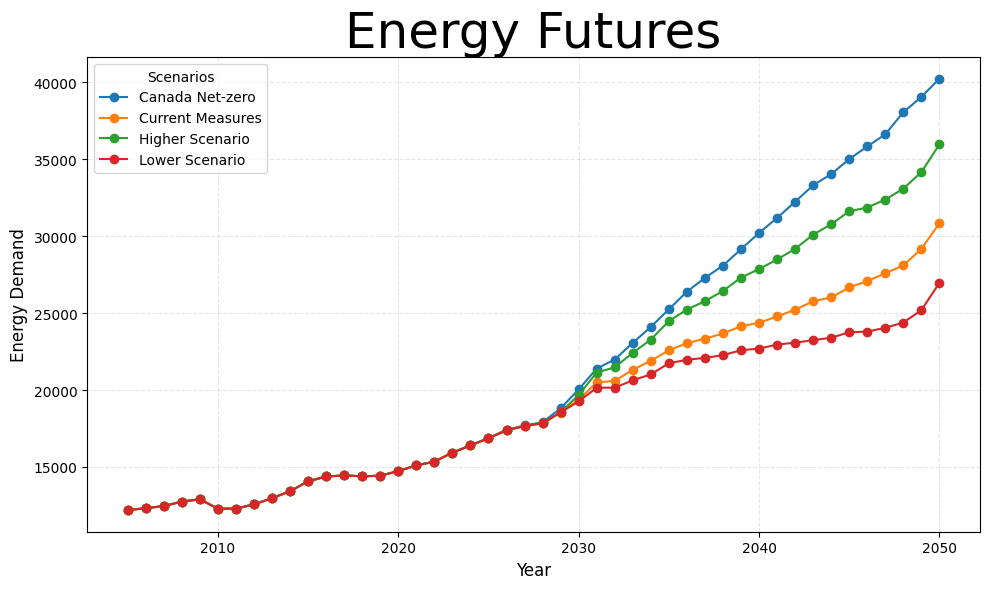

In [7]:
# 1. create the plot
ax = df_canada.plot (kind = 'line', marker = 'o', figsize= (10,6))

# 2. professional styling

plt.title('Energy Futures', fontsize = 36)
plt.xlabel('Year', fontsize = 12)
plt.ylabel ('Energy Demand', fontsize = 12)
plt.grid(True, linestyle = '--', alpha = .3)
plt.legend( title = 'Scenarios', loc= 'upper left')

# plt.legend( title = 'Scenarios', bbox_to_anchor=(1.05,1),loc= 'upper left')

# 3.display
plt.tight_layout()
plt.show()

In [58]:
df_canada_future = df[(df['Region']=='Canada') 
                      &
                      (df['Year']>= 2026)].pivot_table(
                          index = 'Year',
                          columns = 'Scenario',
                          values = 'Value'
                      ).sort_index()

In [59]:
df_canada_future.head()

Scenario,Canada Net-zero,Current Measures,Higher Scenario,Lower Scenario
Year,,,,
2026,17416.8299,17383.5312,17383.5312,17383.5312
2027,17705.3047,17660.9064,17660.9064,17660.9064
2028,17901.0320,17831.5512,17844.3890,17847.8264
2029,18815.9944,18536.1426,18556.3293,18548.6238
2030,20040.5850,19374.0729,19677.6454,19260.4151


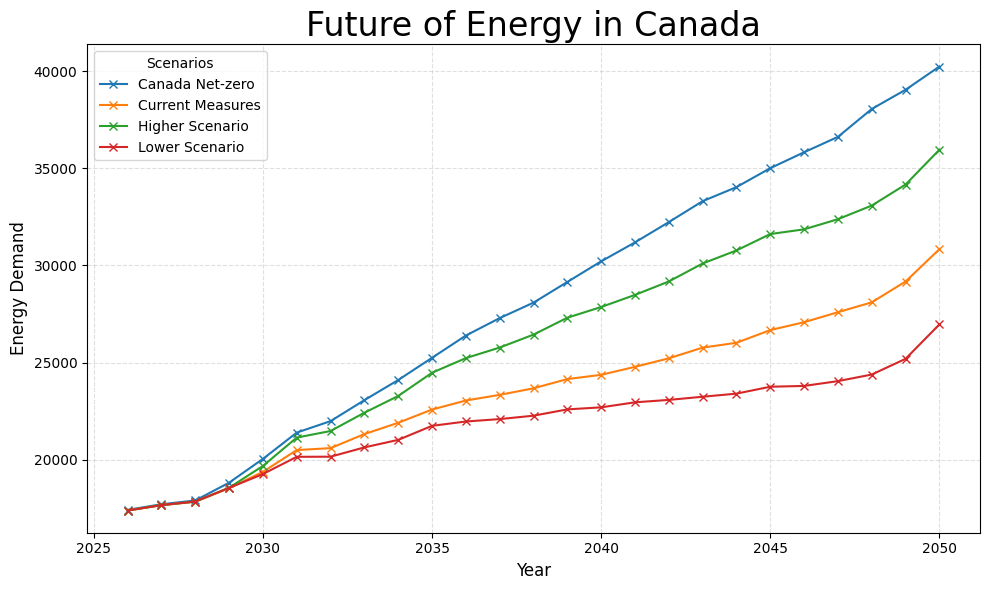

In [75]:
ax = df_canada_future.plot(kind='line', marker = 'x', figsize =(10,6))
plt.title('Future of Energy in Canada', fontsize = 24)
plt.xlabel('Year', fontsize = 12)
plt.ylabel('Energy Demand', fontsize=12)
plt.grid( True, linestyle = '--', alpha = 0.4)
plt.legend (title = 'Scenarios', loc = 'upper left')
plt.tight_layout()
plt.show()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19401 entries, 0 to 19400
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Scenario  19401 non-null  object 
 1   Region    19401 non-null  object 
 2   Variable  19401 non-null  object 
 3   Type      19401 non-null  object 
 4   Year      19401 non-null  int64  
 5   Value     19401 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 909.5+ KB


In [21]:
print(df.shape)
print(df.columns)


(19401, 6)
Index(['Scenario', 'Region', 'Variable', 'Type', 'Year', 'Value'], dtype='object')


In [22]:
df.isnull().sum()

Scenario    0
Region      0
Variable    0
Type        0
Year        0
Value       0
dtype: int64

In [26]:
df['Scenario'].unique()

array(['Canada Net-zero', 'Current Measures', 'Higher Scenario',
       'Lower Scenario'], dtype=object)

In [29]:
print(df['Region'].unique())
print(df['Region'].value_counts())

['Alberta' 'British Columbia' 'Canada' 'Manitoba' 'New Brunswick'
 'Newfoundland and Labrador' 'Northwest Territories' 'Nova Scotia'
 'Nunavut' 'Ontario' 'Prince Edward Island' 'Quebec' 'Saskatchewan'
 'Yukon']
Region
Canada                       1840
Alberta                      1656
New Brunswick                1656
Nova Scotia                  1656
Saskatchewan                 1656
Ontario                      1492
British Columbia             1472
Quebec                       1472
Manitoba                     1308
Newfoundland and Labrador    1288
Northwest Territories        1104
Yukon                        1104
Prince Edward Island          920
Nunavut                       777
Name: count, dtype: int64


In [30]:
print(df['Variable'].unique())
print(df['Variable'].value_counts())

['Battery Storage' 'Biomass / Geothermal' 'Coal & Coke'
 'Hydro / Wave / Tidal' 'Natural Gas' 'Oil' 'Solar' 'Uranium' 'Wind'
 'Hydrogen']
Variable
Battery Storage         2576
Oil                     2576
Solar                   2576
Wind                    2576
Hydro / Wave / Tidal    2249
Natural Gas             2208
Biomass / Geothermal    2024
Uranium                 1288
Coal & Coke              960
Hydrogen                 368
Name: count, dtype: int64


In [31]:
print(df['Type'].unique())
print(df['Type'].value_counts())

['Primary Fuel']
Type
Primary Fuel    19401
Name: count, dtype: int64


In [32]:
df.Type.head(5)

0    Primary Fuel
1    Primary Fuel
2    Primary Fuel
3    Primary Fuel
4    Primary Fuel
Name: Type, dtype: object

In [13]:
# Filter for Ontario and the past 20 years
ontario_growth = df[(df['Region'] == 'Ontario') & (df['Year'] >= 2005)]
print(ontario_growth.head())

             Scenario   Region         Variable          Type  Year  Value
3220  Canada Net-zero  Ontario  Battery Storage  Primary Fuel  2005    0.0
3221  Canada Net-zero  Ontario  Battery Storage  Primary Fuel  2006    0.0
3222  Canada Net-zero  Ontario  Battery Storage  Primary Fuel  2007    0.0
3223  Canada Net-zero  Ontario  Battery Storage  Primary Fuel  2008    0.0
3224  Canada Net-zero  Ontario  Battery Storage  Primary Fuel  2009    0.0
